<a href="https://colab.research.google.com/github/anteodor/Numerical-Methods/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory Work: Numerical Methods
**Student:** Anastasiia Teodorovska   
**Language:** Python (Google Colab)




## Task 1. Analysis of a Simplified Floating-Point Representation

### 1. Problem Statement

The objective of this task is to analyze a simplified floating-point representation system and determine all real numbers that can be represented within it.

The floating-point representation is defined as:

$$
rd(x) = (-1)^k \cdot (0.d_1 d_2)_2 \cdot 2^{(e - b)},
$$

where:

- $k$ is the sign bit,
- $d_1, d_2$ are the mantissa bits,
- $e$ is the exponent encoded using 2 bits,
- $b = 1$ is the bias.

The task requires:

- determining all possible representable real numbers;
- identifying the largest and smallest representable values;
- determining the smallest positive nonzero number;
- presenting the results both analytically and in tabular form.

### 2. Mathematical Background

The floating-point representation consists of three main components: sign, mantissa, and exponent.

The mantissa is represented in normalized binary fractional form:

$$
(0.d_1 d_2)_2,
$$

which yields the following possible values:

$$
0,\quad \frac{1}{4},\quad \frac{1}{2},\quad \frac{3}{4}.
$$

The exponent is encoded using two bits:

$$
e \in \{0,1,2,3\}.
$$

Taking into account the bias $b = 1$, the actual exponent becomes:

$$
E = e - b = e - 1,
$$

thus:

$$
E \in \{-1, 0, 1, 2\}.
$$

The corresponding powers of two are:

$$
2^E \in \left\{\frac{1}{2},\;1,\;2,\;4\right\}.
$$

Each representable number is computed as:

$$
x = (-1)^k \cdot M \cdot 2^E,
$$

where $M$ is the mantissa value.

By combining all possible mantissas, exponents, and signs, a finite set of representable real numbers is obtained.

### 3. Methodology

The implementation consists of the following steps:

1. Generation of all possible combinations of bits:
   - sign bit $k \in \{0,1\}$,
   - mantissa bits $d_1, d_2 \in \{0,1\}$,
   - exponent bits $e_1, e_2 \in \{0,1\}$.

2. Computation of the mantissa value:

$$
M = d_1 \cdot 2^{-1} + d_2 \cdot 2^{-2}.
$$

3. Decoding of the exponent:

$$
e = 2 \cdot e_1 + e_2,
$$

$$
E = e - b.
$$

4. Calculation of the floating-point value:

$$
x = (-1)^k \cdot M \cdot 2^E.
$$

5. Storage of all computed values and elimination of duplicates.

6. Sorting of the resulting set of representable numbers.

7. Determination of:
   - the largest representable value,
   - the smallest representable value,
   - the smallest positive nonzero value.

8. Presentation of the results as:
   - a mathematical set of values,
   - a detailed table of all representations.

### 4. Results and Analysis

The obtained results show that the set of representable numbers is finite and symmetric with respect to zero.

The complete set of distinct representable values is:

$$
\{-3,\,-2,\,-\tfrac{3}{2},\,-1,\,-\tfrac{3}{4},\,-\tfrac{1}{2},\,-\tfrac{3}{8},\,-\tfrac{1}{4},\,-\tfrac{1}{8},\,
0,\,
\tfrac{1}{8},\;\tfrac{1}{4},\;\tfrac{3}{8},\;\tfrac{1}{2},\;\tfrac{3}{4},\;1,\;\tfrac{3}{2},\;2,\;3\}.
$$

The following key observations can be made:

- the representation includes both positive and negative values due to the sign bit;
- zero appears as a special case and may have multiple binary representations;
- the spacing between consecutive numbers is non-uniform, reflecting the influence of the exponent;
- the density of representable numbers is higher near zero.

The extreme values are:

$$
x_{\max} = 3, \quad x_{\min} = -3.
$$

The smallest positive nonzero number is:

$$
x_{\min}^{+} = \frac{1}{8}.
$$

The tabular representation of all bit combinations confirms the correctness of the analytical derivation.

### 5. Conclusion

In this task, a simplified floating-point system was analyzed both analytically and programmatically.

All possible combinations of sign, mantissa, and exponent bits were systematically generated, allowing the complete set of representable real numbers to be determined.

The results demonstrate that the floating-point system produces a finite set of values with non-uniform distribution. The presence of a bias in the exponent and the limited number of mantissa bits significantly affect both the range and precision of representable numbers.

The largest and smallest representable values were found to be $3$ and $-3$, respectively, while the smallest positive nonzero number was determined to be $\frac{1}{8}$.

This task illustrates fundamental concepts of floating-point arithmetic, including limited precision, discrete representation, and the influence of exponent scaling on numerical values.

In [9]:
# Task 1 — Floating-point system simulation

from itertools import product
import pandas as pd

bias = 1

representations = []
values = []

for k, d1, d2, e1, e2 in product([0, 1], repeat=5):
    # Mantissa: (0.d1 d2)_2
    mantissa = d1 * 2**(-1) + d2 * 2**(-2)

    # Exponent (2 bits)
    e = e1 * 2 + e2
    actual_exponent = e - bias

    # Floating-point value
    x = ((-1) ** k) * mantissa * (2 ** actual_exponent)

    representations.append({
        "k (sign)": k,
        "d1": d1,
        "d2": d2,
        "e1": e1,
        "e2": e2,
        "mantissa": mantissa,
        "stored exponent (e)": e,
        "actual exponent (e-b)": actual_exponent,
        "value": x
    })

    values.append(x)

# Distinct representable values (as a mathematical set)
unique_values = sorted(set(values))

formatted_set = "{ " + "; ".join(f"{v:g}" for v in unique_values) + " }"

print("All distinct representable values:")
print(formatted_set)

# Summary
print("\nSummary:")
print("Largest value:", max(unique_values))
print("Smallest value:", min(unique_values))

positive_nonzero = [v for v in unique_values if v > 0]
print("Smallest positive nonzero value:", min(positive_nonzero))

# Full table of all representations
df = pd.DataFrame(representations)
df_sorted = df.sort_values(by="value")

print("\nFull table of all floating-point representations:\n")
display(
    df_sorted.style
    .format({
        "mantissa": "{:.3f}",
        "value": "{:.3f}"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("text-align", "left")]}
    ])
)

All distinct representable values:
{ -3; -2; -1.5; -1; -0.75; -0.5; -0.375; -0.25; -0.125; 0; 0.125; 0.25; 0.375; 0.5; 0.75; 1; 1.5; 2; 3 }

Summary:
Largest value: 3.0
Smallest value: -3.0
Smallest positive nonzero value: 0.125

Full table of all floating-point representations:



,k (sign),d1,d2,e1,e2,mantissa,stored exponent (e),actual exponent (e-b),value
31,1,1,1,1,1,0.750,3,2,-3.000
27,1,1,0,1,1,0.500,3,2,-2.000
30,1,1,1,1,0,0.750,2,1,-1.500
23,1,0,1,1,1,0.250,3,2,-1.000
26,1,1,0,1,0,0.500,2,1,-1.000
29,1,1,1,0,1,0.750,1,0,-0.750
22,1,0,1,1,0,0.250,2,1,-0.500
25,1,1,0,0,1,0.500,1,0,-0.500
28,1,1,1,0,0,0.750,0,-1,-0.375
21,1,0,1,0,1,0.250,1,0,-0.250


## Task 2. Floating-Point Precision Analysis

### 1. Problem Statement

The objective of this task is to investigate the precision limitations of floating-point arithmetic.

Specifically, it is required to:

- compute the expression:

$$
1 + \varepsilon, \quad \text{where} \quad \varepsilon = \frac{1}{2^n}, \quad n = 0, 1, 2, \dots
$$

- analyze how the value of $\varepsilon$ influences the result of the computation;
- determine the smallest value of $\varepsilon$ for which:

$$
1 + \varepsilon \neq 1;
$$

- identify the threshold at which:

$$
1 + \varepsilon = 1
$$

due to finite precision of floating-point representation;

- perform the analysis for different floating-point formats:
  - $\texttt{float16}$,
  - $\texttt{float32}$,
  - $\texttt{float64}$,
  - $\texttt{float128}$ (if supported);

- present the results in tabular form and compare the obtained precision limits.

### 2. Mathematical Background

In floating-point arithmetic, real numbers are represented with finite precision. As a result, very small values may not affect the result of arithmetic operations.

In this task, the parameter $\varepsilon$ is defined as:

$$
\varepsilon = \frac{1}{2^n}.
$$

As $n$ increases, the value of $\varepsilon$ decreases:

$$
\lim_{n \to \infty} \varepsilon = 0.
$$

However, due to finite precision, there exists a threshold value $\varepsilon_{\text{min}}$ such that:

$$
1 + \varepsilon_{\text{min}} > 1,
$$

but for smaller values:

$$
1 + \varepsilon = 1.
$$

This phenomenon occurs because the floating-point representation cannot distinguish between numbers that differ by less than a certain precision.

The smallest value $\varepsilon$ that still satisfies:

$$
1 + \varepsilon > 1
$$

is closely related to the concept of machine precision (machine epsilon).

Machine epsilon is defined as the smallest number $\varepsilon$ such that:

$$
1 + \varepsilon \neq 1.
$$

### 3. Methodology

The implementation consists of the following steps:

1. Selection of floating-point formats:
   - $\texttt{float16}$,
   - $\texttt{float32}$,
   - $\texttt{float64}$,
   - $\texttt{float128}$ (if available).

2. For each data type, a sequence of values $\varepsilon$ is generated using:

$$
\varepsilon = \frac{1}{2^n}, \quad n = 0, 1, 2, \dots
$$

3. For each value of $n$, the expression:

$$
1 + \varepsilon
$$

is computed.

4. A logical condition is evaluated:

$$
1 + \varepsilon \neq 1,
$$

which determines whether the value of $\varepsilon$ still affects the result.

5. The following values are recorded:
   - $n$,
   - $\varepsilon$,
   - $1 + \varepsilon$,
   - a boolean indicator showing whether the value changes.

6. The algorithm identifies:
   - the largest $n$ such that:

$$
1 + \varepsilon > 1,
$$

   - the smallest $n$ such that:

$$
1 + \varepsilon = 1.
$$

7. The results are presented in tabular form and summarized for comparison between different floating-point formats.

### 4. Results and Analysis

The obtained results demonstrate the limitations of floating-point precision.

For each floating-point format, it was observed that as $n$ increases, the value of $\varepsilon = \frac{1}{2^n}$ decreases rapidly. Initially, the expression:

$$
1 + \varepsilon
$$

produces a value strictly greater than 1. However, beyond a certain threshold, further decreases in $\varepsilon$ no longer affect the result, and the expression becomes:

$$
1 + \varepsilon = 1.
$$

This threshold depends on the precision of the floating-point format:

- $\texttt{float16}$ reaches the precision limit at relatively small values of $n$;
- $\texttt{float32}$ allows smaller values of $\varepsilon$ to be distinguished;
- $\texttt{float64}$ provides significantly higher precision;
- $\texttt{float128}$ (if available) demonstrates the highest precision among the considered formats.

The results clearly show that higher precision formats can represent smaller differences between numbers.

The final summary table confirms that the value of $\varepsilon_{\text{min}}$ decreases as the number of bits in the floating-point representation increases.

This behavior illustrates the fundamental limitation of floating-point arithmetic: numbers that are too close to each other cannot be distinguished due to rounding.

### 5. Conclusion

In this task, the precision limits of floating-point arithmetic were investigated through numerical experiments.

The study demonstrated that for sufficiently small values of $\varepsilon$, the expression:

$$
1 + \varepsilon = 1
$$

due to the finite precision of floating-point representation.

The experiments confirmed that each floating-point format has its own threshold below which values of $\varepsilon$ no longer influence the result. This threshold corresponds to the machine precision of the given format.

It was also shown that increasing the number of bits in the floating-point representation leads to a significant improvement in precision, allowing smaller values of $\varepsilon$ to be distinguished.

Overall, this task highlights the importance of understanding numerical precision and its impact on computations, which is a fundamental concept in numerical methods and scientific computing.

In [10]:
# Task 2 — Floating-point precision analysis

import numpy as np
import pandas as pd

def run_experiment(dtype, dtype_name, max_n):

    records = []
    precision_limit_n = None
    last_effective_n = None
    last_effective_eps = None

    one = dtype(1.0)
    two = dtype(2.0)

    for n in range(max_n + 1):
        epsilon = one / (two ** n)
        result = one + epsilon
        changed = result != one

        records.append({
            "n": n,
            "epsilon": float(epsilon),
            "1 + epsilon": float(result),
            "changes": changed
        })

        if changed:
            last_effective_n = n
            last_effective_eps = float(epsilon)
        elif precision_limit_n is None:
            precision_limit_n = n
            print(f"\nPrecision limit reached at n = {n}")
            print(f"(epsilon is too small to change 1 in {dtype_name})\n")
            break

    df = pd.DataFrame(records)

    limit_info = {
        "dtype": dtype_name,
        "last n where 1 + epsilon > 1": last_effective_n,
        "last effective epsilon": last_effective_eps,
        "first n where 1 + epsilon = 1": precision_limit_n
    }

    return df, limit_info


# Run experiments for different floating-point formats
experiments = [
    (np.float16, "float16 (16-bit)", 20),
    (np.float32, "float32 (32-bit)", 40),
    (np.float64, "float64 (64-bit)", 60),
]


# Add float128 only if supported
if hasattr(np, "float128"):
    experiments.append((np.float128, "float128 (128-bit)", 100))

all_summaries = []

for dtype, dtype_name, max_n in experiments:
    print("=" * 70)
    print(dtype_name)
    print("=" * 70)

    df, summary = run_experiment(dtype, dtype_name, max_n)
    all_summaries.append(summary)

    display(
        df.style
        .format({
            "epsilon": "{:.20e}",
            "1 + epsilon": "{:.20e}"
        })
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left")]},
            {"selector": "td", "props": [("text-align", "left")]}
        ])
    )


# Final summary table
summary_df = pd.DataFrame(all_summaries)

print("=" * 70)
print("Final summary for all precisions")
print("=" * 70)
display(
    summary_df.style
    .format({
        "last effective epsilon": "{:.20e}"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("text-align", "left")]}
    ])
)

float16 (16-bit)

Precision limit reached at n = 11
(epsilon is too small to change 1 in float16 (16-bit))



,n,epsilon,1 + epsilon,changes
0,0,1.00000000000000000000e+00,2.00000000000000000000e+00,True
1,1,5.00000000000000000000e-01,1.50000000000000000000e+00,True
2,2,2.50000000000000000000e-01,1.25000000000000000000e+00,True
3,3,1.25000000000000000000e-01,1.12500000000000000000e+00,True
4,4,6.25000000000000000000e-02,1.06250000000000000000e+00,True
5,5,3.12500000000000000000e-02,1.03125000000000000000e+00,True
6,6,1.56250000000000000000e-02,1.01562500000000000000e+00,True
7,7,7.81250000000000000000e-03,1.00781250000000000000e+00,True
8,8,3.90625000000000000000e-03,1.00390625000000000000e+00,True
9,9,1.95312500000000000000e-03,1.00195312500000000000e+00,True


float32 (32-bit)

Precision limit reached at n = 24
(epsilon is too small to change 1 in float32 (32-bit))



,n,epsilon,1 + epsilon,changes
0,0,1.00000000000000000000e+00,2.00000000000000000000e+00,True
1,1,5.00000000000000000000e-01,1.50000000000000000000e+00,True
2,2,2.50000000000000000000e-01,1.25000000000000000000e+00,True
3,3,1.25000000000000000000e-01,1.12500000000000000000e+00,True
4,4,6.25000000000000000000e-02,1.06250000000000000000e+00,True
5,5,3.12500000000000000000e-02,1.03125000000000000000e+00,True
6,6,1.56250000000000000000e-02,1.01562500000000000000e+00,True
7,7,7.81250000000000000000e-03,1.00781250000000000000e+00,True
8,8,3.90625000000000000000e-03,1.00390625000000000000e+00,True
9,9,1.95312500000000000000e-03,1.00195312500000000000e+00,True


float64 (64-bit)

Precision limit reached at n = 53
(epsilon is too small to change 1 in float64 (64-bit))



,n,epsilon,1 + epsilon,changes
0,0,1.00000000000000000000e+00,2.00000000000000000000e+00,True
1,1,5.00000000000000000000e-01,1.50000000000000000000e+00,True
2,2,2.50000000000000000000e-01,1.25000000000000000000e+00,True
3,3,1.25000000000000000000e-01,1.12500000000000000000e+00,True
4,4,6.25000000000000000000e-02,1.06250000000000000000e+00,True
5,5,3.12500000000000000000e-02,1.03125000000000000000e+00,True
6,6,1.56250000000000000000e-02,1.01562500000000000000e+00,True
7,7,7.81250000000000000000e-03,1.00781250000000000000e+00,True
8,8,3.90625000000000000000e-03,1.00390625000000000000e+00,True
9,9,1.95312500000000000000e-03,1.00195312500000000000e+00,True


float128 (128-bit)

Precision limit reached at n = 64
(epsilon is too small to change 1 in float128 (128-bit))



,n,epsilon,1 + epsilon,changes
0,0,1.00000000000000000000e+00,2.00000000000000000000e+00,True
1,1,5.00000000000000000000e-01,1.50000000000000000000e+00,True
2,2,2.50000000000000000000e-01,1.25000000000000000000e+00,True
3,3,1.25000000000000000000e-01,1.12500000000000000000e+00,True
4,4,6.25000000000000000000e-02,1.06250000000000000000e+00,True
5,5,3.12500000000000000000e-02,1.03125000000000000000e+00,True
6,6,1.56250000000000000000e-02,1.01562500000000000000e+00,True
7,7,7.81250000000000000000e-03,1.00781250000000000000e+00,True
8,8,3.90625000000000000000e-03,1.00390625000000000000e+00,True
9,9,1.95312500000000000000e-03,1.00195312500000000000e+00,True


Final summary for all precisions


,dtype,last n where 1 + epsilon > 1,last effective epsilon,first n where 1 + epsilon = 1
0,float16 (16-bit),10,9.76562500000000000000e-04,11
1,float32 (32-bit),23,1.19209289550781250000e-07,24
2,float64 (64-bit),52,2.22044604925031308085e-16,53
3,float128 (128-bit),63,1.08420217248550443401e-19,64


## Task 3. Taylor Series Approximation of Trigonometric Functions

### 1. Problem Statement

The objective of this task is to investigate the approximation of trigonometric functions using Taylor series expansions.

Specifically, it is required to:

- implement numerical approximations of the functions $\sin(x)$ and $\cos(x)$ using a finite number of terms of their Taylor series;
- compare the obtained approximations with the corresponding values computed by the NumPy library;
- analyze the approximation error for both functions;
- evaluate the deviation from the fundamental trigonometric identity:

$$
\sin^2(x) + \cos^2(x) = 1;
$$

- study how the approximation accuracy depends on the number of terms in the Taylor series;
- visualize the obtained results using graphical representations.

### 2. Mathematical Background

The Taylor series expansion of a function provides a polynomial approximation around a given point. In this task, the expansions are performed around $x = 0$, which corresponds to the Maclaurin series.

The Taylor series for the sine function is given by:

$$
\sin(x) = \sum_{n=0}^{\infty} \frac{(-1)^n x^{2n+1}}{(2n+1)!}
$$

Similarly, the cosine function is represented as:

$$
\cos(x) = \sum_{n=0}^{\infty} \frac{(-1)^n x^{2n}}{(2n)!}
$$

In practical computations, only a finite number of terms $n$ is used, which leads to an approximation error. The magnitude of this error depends on both the number of terms and the distance of $x$ from the expansion point.

The approximation error is defined as:

$$
\text{error} = f_{\text{exact}}(x) - f_{\text{approx}}(x)
$$

Additionally, the deviation from the trigonometric identity is evaluated as:

$$
\sin^2(x) + \cos^2(x) - 1
$$

which should ideally be equal to zero. Any deviation indicates numerical inaccuracies caused by truncation of the Taylor series.

### 3. Methodology

The implementation consists of the following steps:

1. Definition of functions for computing Taylor series approximations of $\sin(x)$ and $\cos(x)$ using a specified number of terms.

2. Generation of a set of input values $x$ within the interval $[-\pi, \pi]$.

3. Computation of:
   - exact function values using NumPy;
   - approximate values using Taylor series.

4. Evaluation of approximation errors for both functions:
   
$$
\text{error}_{\sin}(x) = \sin_{\text{exact}}(x) - \sin_{\text{approx}}(x)
$$

$$
\text{error}_{\cos}(x) = \cos_{\text{exact}}(x) - \cos_{\text{approx}}(x)
$$

5. Calculation of the deviation from the identity:

$$
\sin^2(x) + \cos^2(x) - 1
$$

6. Construction of a comparison table for selected values of $x$.

7. Visualization of:
   - exact and approximate functions;
   - approximation errors;
   - identity deviation.

8. Analysis of how the approximation accuracy changes with different numbers of Taylor series terms.

### 4. Results and Analysis

The obtained results demonstrate that Taylor series approximations provide high accuracy in the vicinity of the expansion point $x = 0$. In this region, the approximation closely matches the exact values computed by NumPy.

However, as the value of $x$ moves away from zero, the approximation error increases. This behavior is expected, as the Taylor series is inherently a local approximation.

The graphical analysis confirms that:

- the difference between the exact and approximate functions is minimal near the origin;
- the approximation error grows towards the boundaries of the interval $[-\pi, \pi]$;
- the deviation from the identity

$$
\sin^2(x) + \cos^2(x) - 1
$$

increases with the error of the approximations.

Furthermore, the analysis of different numbers of Taylor series terms shows that:

- increasing the number of terms significantly improves accuracy;
- the rate of convergence is faster near the expansion point;
- for larger values of $x$, more terms are required to achieve the same level of accuracy.

These results illustrate the trade-off between computational cost and approximation accuracy.

### 5. Conclusion

In this task, the Taylor series approximations of the functions $\sin(x)$ and $\cos(x)$ were successfully implemented and analyzed.

The study demonstrated that Taylor series provide an effective method for approximating smooth functions, particularly in the vicinity of the expansion point $x = 0$. However, the accuracy decreases as the argument moves away from this point due to truncation errors.

The comparison with NumPy results confirmed the correctness of the implementation, while the graphical analysis provided clear insight into the behavior of approximation errors.

Additionally, the evaluation of the identity

$$
\sin^2(x) + \cos^2(x) = 1
$$

revealed the accumulation of numerical errors in approximate computations.

Overall, this task highlights fundamental concepts of numerical analysis, including series approximation, truncation error, and the dependence of accuracy on both the number of terms and the domain of evaluation.

Number of Taylor series terms: 8

Maximum absolute error for sin approximation: 7.727858895531034e-07
Maximum absolute error for cos approximation: 4.16780914247461e-06
Maximum absolute value of sin^2(x) + cos^2(x) - 1: 8.33563625279865e-06


,x,numpy.sin(x),Taylor sin(x),sin error,numpy.cos(x),Taylor cos(x),cos error,sin^2+cos^2-1
0,-3.141593,-1.22464679914735320717e-16,7.72785889430638740089e-07,-7.72785889553103398877e-07,-1.00000000000000000000e+00,-1.00000416780914247461e+00,4.16780914247460998467e-06,0.000008
1,-1.570796,-1.00000000000000000000e+00,-9.99999999993976818047e-01,-6.02318195319639926311e-12,6.12323399573676603587e-17,-6.51335680512734659553e-11,6.51336292836134198014e-11,-0.000000
2,-0.785398,-7.07106781186547461715e-01,-7.07106781186547461715e-01,0.00000000000000000000e+00,7.07106781186547572737e-01,7.07106781186546462514e-01,1.11022302462515654042e-15,-0.000000
3,0.000000,0.00000000000000000000e+00,0.00000000000000000000e+00,0.00000000000000000000e+00,1.00000000000000000000e+00,1.00000000000000000000e+00,0.00000000000000000000e+00,0.000000
4,0.785398,7.07106781186547461715e-01,7.07106781186547461715e-01,0.00000000000000000000e+00,7.07106781186547572737e-01,7.07106781186546462514e-01,1.11022302462515654042e-15,-0.000000
5,1.570796,1.00000000000000000000e+00,9.99999999993976818047e-01,6.02318195319639926311e-12,6.12323399573676603587e-17,-6.51335680512734659553e-11,6.51336292836134198014e-11,-0.000000
6,3.141593,1.22464679914735320717e-16,-7.72785889430638740089e-07,7.72785889553103398877e-07,-1.00000000000000000000e+00,-1.00000416780914247461e+00,4.16780914247460998467e-06,0.000008



Error summary for different numbers of Taylor series terms:



,number of terms,max |sin error|,max |cos error|,max |sin^2 + cos^2 - 1|
0,2,2.02612012646017625173e+00,2.93480220054467899615e+00,1.85878311242582476837e+01
1,4,7.52206159036231808424e-02,2.11352842982500677138e-01,4.73033851258707338516e-01
2,6,4.45160238209335232511e-04,1.82910401362157415406e-03,3.66175181637351521147e-03
3,8,7.72785889553103398877e-07,4.16780914247460998467e-06,8.33563625279865050288e-06
4,10,5.28918402822438866769e-10,3.52908013923070029705e-09,7.05816027846140059410e-09
5,12,1.70408278558471891683e-13,1.35647049148701626109e-12,2.71294098297403252218e-12


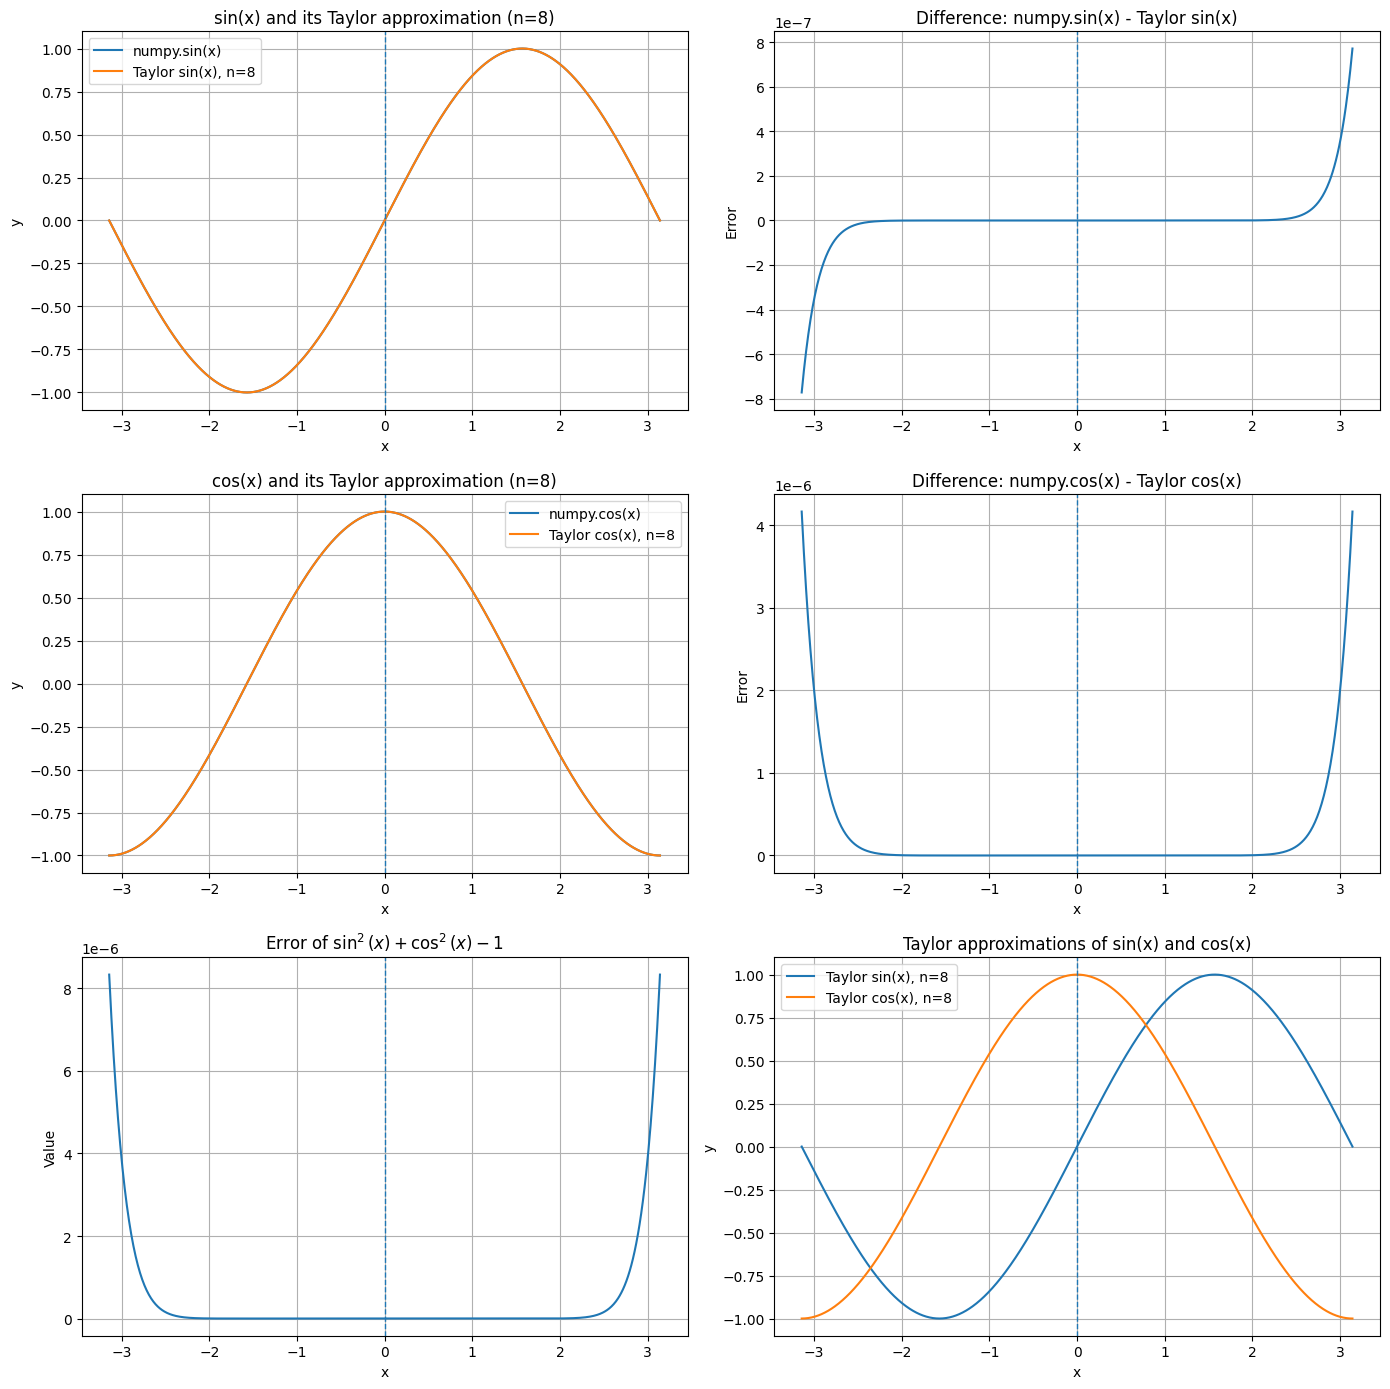

In [11]:
# Task 3 — Taylor series approximation of sin(x) and cos(x)

import numpy as np
import matplotlib.pyplot as plt
from math import factorial


# Taylor series approximations
def taylor_sin(x, n_terms):
    x = np.asarray(x, dtype=np.float64)
    result = np.zeros_like(x)
    for n in range(n_terms):
        result += ((-1) ** n) * (x ** (2 * n + 1)) / factorial(2 * n + 1)
    return result


def taylor_cos(x, n_terms):
    x = np.asarray(x, dtype=np.float64)
    result = np.zeros_like(x)
    for n in range(n_terms):
        result += ((-1) ** n) * (x ** (2 * n)) / factorial(2 * n)
    return result


# Parameters
n_terms = 8                  # number of Taylor series terms
x = np.linspace(-np.pi, np.pi, 1000)

# Exact values
sin_np = np.sin(x)
cos_np = np.cos(x)

# Taylor approximations
sin_taylor = taylor_sin(x, n_terms)
cos_taylor = taylor_cos(x, n_terms)

# Differences
sin_error = sin_np - sin_taylor
cos_error = cos_np - cos_taylor

# Identity error
identity_error = sin_taylor**2 + cos_taylor**2 - 1

# Table of selected points
sample_points = np.array([
    -np.pi, -np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2, np.pi
])

table = pd.DataFrame({
    "x": sample_points,
    "numpy.sin(x)": np.sin(sample_points),
    "Taylor sin(x)": taylor_sin(sample_points, n_terms),
    "sin error": np.sin(sample_points) - taylor_sin(sample_points, n_terms),
    "numpy.cos(x)": np.cos(sample_points),
    "Taylor cos(x)": taylor_cos(sample_points, n_terms),
    "cos error": np.cos(sample_points) - taylor_cos(sample_points, n_terms),
    "sin^2+cos^2-1": taylor_sin(sample_points, n_terms)**2 + taylor_cos(sample_points, n_terms)**2 - 1
})


# Print numerical summary
print(f"Number of Taylor series terms: {n_terms}\n")
print("Maximum absolute error for sin approximation:", np.max(np.abs(sin_error)))
print("Maximum absolute error for cos approximation:", np.max(np.abs(cos_error)))
print("Maximum absolute value of sin^2(x) + cos^2(x) - 1:", np.max(np.abs(identity_error)))

display(
    table.style
    .format({
        "x": "{:.6f}",
        "numpy.sin(x)": "{:.20e}",
        "Taylor sin(x)": "{:.20e}",
        "sin error": "{:.20e}",
        "numpy.cos(x)": "{:.20e}",
        "Taylor cos(x)": "{:.20e}",
        "cos error": "{:.20e}",
        "sin^2 + cos^2 - 1": "{:.20e}"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("text-align", "left")]}
    ])
)


# Error analysis for different numbers of Taylor terms
terms_list = [2, 4, 6, 8, 10, 12]
summary_records = []

for terms in terms_list:
    sin_approx = taylor_sin(x, terms)
    cos_approx = taylor_cos(x, terms)

    sin_err = np.max(np.abs(np.sin(x) - sin_approx))
    cos_err = np.max(np.abs(np.cos(x) - cos_approx))
    ident_err = np.max(np.abs(sin_approx**2 + cos_approx**2 - 1))

    summary_records.append({
        "number of terms": terms,
        "max |sin error|": sin_err,
        "max |cos error|": cos_err,
        "max |sin^2 + cos^2 - 1|": ident_err
    })

summary_df = pd.DataFrame(summary_records)

print("\nError summary for different numbers of Taylor series terms:\n")
display(
    summary_df.style
    .format({
        "max |sin error|": "{:.20e}",
        "max |cos error|": "{:.20e}",
        "max |sin^2 + cos^2 - 1|": "{:.20e}"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("text-align", "left")]}
    ])
)


# Plotting
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# 1. sin(x): NumPy vs Taylor
axes[0, 0].plot(x, sin_np, label='numpy.sin(x)')
axes[0, 0].plot(x, sin_taylor, label=f'Taylor sin(x), n={n_terms}')
axes[0, 0].axvline(0, linestyle='--', linewidth=1)
axes[0, 0].set_title(f'sin(x) and its Taylor approximation (n={n_terms})')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].grid(True)
axes[0, 0].legend()

# 2. Difference for sin
axes[0, 1].plot(x, sin_error)
axes[0, 1].axvline(0, linestyle='--', linewidth=1)
axes[0, 1].set_title('Difference: numpy.sin(x) - Taylor sin(x)')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('Error')
axes[0, 1].grid(True)

# 3. cos(x): NumPy vs Taylor
axes[1, 0].plot(x, cos_np, label='numpy.cos(x)')
axes[1, 0].plot(x, cos_taylor, label=f'Taylor cos(x), n={n_terms}')
axes[1, 0].axvline(0, linestyle='--', linewidth=1)
axes[1, 0].set_title(f'cos(x) and its Taylor approximation (n={n_terms})')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')
axes[1, 0].grid(True)
axes[1, 0].legend()

# 4. Difference for cos
axes[1, 1].plot(x, cos_error)
axes[1, 1].axvline(0, linestyle='--', linewidth=1)
axes[1, 1].set_title('Difference: numpy.cos(x) - Taylor cos(x)')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('Error')
axes[1, 1].grid(True)

# 5. Trigonometric identity error
axes[2, 0].plot(x, identity_error)
axes[2, 0].axvline(0, linestyle='--', linewidth=1)
axes[2, 0].set_title(r'Error of $\sin^2(x) + \cos^2(x) - 1$')
axes[2, 0].set_xlabel('x')
axes[2, 0].set_ylabel('Value')
axes[2, 0].grid(True)

# 6. Taylor approximations together
axes[2, 1].plot(x, sin_taylor, label=f'Taylor sin(x), n={n_terms}')
axes[2, 1].plot(x, cos_taylor, label=f'Taylor cos(x), n={n_terms}')
axes[2, 1].axvline(0, linestyle='--', linewidth=1)
axes[2, 1].set_title('Taylor approximations of sin(x) and cos(x)')
axes[2, 1].set_xlabel('x')
axes[2, 1].set_ylabel('y')
axes[2, 1].grid(True)
axes[2, 1].legend()

plt.tight_layout()
plt.show()